# Projeto: Detecção de Domínios Funcionais em Proteínas
**Disciplina:** Redes Complexas  
**Alvo principal:** 6B1T (Adenovírus Humano 5)  
**Linguagem:** Python  

---

## Pipeline
1. Obtenção e preparação dos dados (PDB)
2. Leitura e parsing do arquivo PDB
3. Construção da rede de contatos entre resíduos
4. Análise topológica (graus, centralidades)
5. Detecção de comunidades (Louvain)
6. Validação biológica
7. Estratégia de teste (proteína pequena antes do alvo)

> **Declaração de uso de IA:** Código auxiliado por Claude Sonnet 4.6 (Anthropic). Temperatura padrão.

## 0. Instalação de dependências

In [2]:
import subprocess, sys

packages = [
    "biopython",        # parsing de PDB
    "networkx",         # construção e análise de grafos
    "python-louvain",   # detecção de comunidades (Louvain)
    "matplotlib",       # visualizações
    "numpy",
    "scipy",
    "pandas",
    "seaborn",
    "scikit-learn",     # ARI e NMI
    "requests",         # download de arquivos PDB
    "tqdm",             # barras de progresso
    "py3Dmol",          # visualização 3D inline (opcional)
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Todas as dependências instaladas com sucesso!")

Todas as dependências instaladas com sucesso!


## 1. Importações e configurações globais

In [3]:
import os
import gzip
import json
import urllib.request
import tarfile
import requests
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations
from tqdm import tqdm
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

# BioPython
from Bio import PDB
from Bio.PDB import PDBParser, MMCIFParser
from Bio.PDB.Polypeptide import is_aa

# Louvain  (import único e canônico — não reimportar em outras células)
import community as community_louvain

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

DATA_DIR = Path("./datav3")
DATA_DIR.mkdir(exist_ok=True)

print("Importações concluídas.")

Importações concluídas.


## 2. Funções utilitárias: download e parsing de PDB

In [4]:
# ─────────────────────────────────────────────────────────────
#  DOWNLOAD
# ─────────────────────────────────────────────────────────────

def download_pdb(pdb_id: str, dest_dir: Path = DATA_DIR) -> Path:
    """
    Tenta baixar via RCSB REST API (formato CIF comprimido).
    Retorna o caminho local do arquivo .cif.gz ou .pdb.gz.
    """
    pdb_id = pdb_id.upper()
    out_path_cif = dest_dir / f"{pdb_id}.cif.gz"
    out_path_pdb = dest_dir / f"{pdb_id}.pdb.gz"

    if out_path_cif.exists():
        print(f"[cache] {pdb_id}.cif.gz já existe.")
        return out_path_cif
    if out_path_pdb.exists():
        print(f"[cache] {pdb_id}.pdb.gz já existe.")
        return out_path_pdb

    urls = [
        (f"https://files.rcsb.org/download/{pdb_id}.cif.gz", out_path_cif),
        (f"https://files.rcsb.org/download/{pdb_id}.pdb.gz", out_path_pdb),
    ]
    for url, path in urls:
        r = requests.get(url, stream=True, timeout=120)
        if r.status_code == 200:
            with open(path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Download concluído: {path}")
            return path

    raise FileNotFoundError(f"Não foi possível baixar {pdb_id} do RCSB.")


def parse_structure(file_path: Path):
    """
    Lê estrutura PDB ou CIF (comprimida ou não).
    Retorna objeto Bio.PDB.Structure.
    """
    name = file_path.stem.replace(".cif", "").replace(".pdb", "").upper()
    suffix = "".join(file_path.suffixes).lower()

    def _open(path):
        if str(path).endswith(".gz"):
            return gzip.open(path, "rt")
        return open(path, "r")

    if ".cif" in suffix:
        parser = MMCIFParser(QUIET=True)
    else:
        parser = PDBParser(QUIET=True)

    with _open(file_path) as fh:
        structure = parser.get_structure(name, fh)

    print(f"Estrutura '{name}' carregada: "
          f"{len(list(structure.get_chains()))} cadeias, "
          f"{len(list(structure.get_residues()))} resíduos.")
    return structure


def get_residue_info(structure) -> pd.DataFrame:
    """
    Extrai DataFrame com um resíduo por linha:
    id_node, chain, resname, resseq, x, y, z (coordenada do Cα ou centroide).
    """
    records = []
    for model in structure:
        for chain in model:
            for res in chain:
                if not is_aa(res, standard=True):
                    continue
                if "CA" in res:
                    coord = res["CA"].get_vector().get_array()
                else:
                    coords = np.array([a.get_vector().get_array() for a in res.get_atoms()])
                    coord = coords.mean(axis=0)
                records.append({
                    "node": f"{chain.id}_{res.get_id()[1]}",
                    "chain": chain.id,
                    "resname": res.get_resname(),
                    "resseq": res.get_id()[1],
                    "x": coord[0],
                    "y": coord[1],
                    "z": coord[2],
                })
        break  # apenas o primeiro modelo
    df = pd.DataFrame(records).drop_duplicates("node").set_index("node")
    print(f"Resíduos padrão (aminoácidos): {len(df)}")
    return df

print("Funções de I/O definidas.")

Funções de I/O definidas.


## 3. Anotações biológicas via RCSB GraphQL

In [5]:
GRAPHQL_URL = "https://data.rcsb.org/graphql"

QUERY = """
query($id:String!){
  entry(entry_id:$id){
    polymer_entities{
      rcsb_polymer_entity{
        pdbx_description
      }
      rcsb_polymer_entity_container_identifiers{
        auth_asym_ids
      }
    }
  }
}
"""

def fetch_chain_annotations(pdb_id: str) -> dict:
    """Retorna {chain_id: descrição_biológica} via RCSB GraphQL."""
    body = json.dumps({
        "query": QUERY,
        "variables": {"id": pdb_id.upper()}
    }).encode()
    req = urllib.request.Request(
        GRAPHQL_URL, data=body,
        headers={"Content-Type": "application/json"}
    )
    with urllib.request.urlopen(req) as r:
        data = json.load(r)
    mapping = {}
    for ent in data["data"]["entry"]["polymer_entities"]:
        name   = ent["rcsb_polymer_entity"]["pdbx_description"]
        chains = ent["rcsb_polymer_entity_container_identifiers"]["auth_asym_ids"]
        for ch in chains:
            mapping[ch] = name
    return mapping


def build_ground_truth_from_chains(df_res: pd.DataFrame, chain_map: dict) -> dict:
    """
    Constrói ground_truth {node_id: label} a partir de {chain_id: label}.
    Nós cujas cadeias não estão no chain_map são ignorados.
    """
    gt = {}
    for node, row in df_res.iterrows():
        label = chain_map.get(row["chain"])
        if label is not None:
            gt[node] = label
    return gt

print("Funções de anotação definidas.")

Funções de anotação definidas.


## 4. Construção da rede de contatos entre resíduos

**Modelagem escolhida — Protein Contact Network (PCN):**

- **Nós:** um por resíduo de aminoácido (posição = Cα)
- **Arestas:** ligação entre dois resíduos se a distância Cα–Cα ≤ `cutoff` Å
- **Pesos:** `w = 1 / d²` (resíduos mais próximos têm ligação mais forte)
- **Justificativa:** é a abordagem mais usada na literatura de redes de proteínas (Atilgan et al. 2004; Vishveshwara et al. 2009). O cutoff de 8 Å captura tanto contatos de cadeia principal quanto interações de cadeia lateral relevantes biologicamente. A ponderação por 1/d² reflete a intensidade decrescente da interação com a distância.

In [6]:
def build_contact_network(
    df_residues: pd.DataFrame,
    cutoff: float = 8.0,
    weight_fn=None,
    chunk_size: int = 2000,
) -> nx.Graph:
    """
    Constrói grafo não-dirigido ponderado de contatos.

    Parâmetros
    ----------
    df_residues : DataFrame com colunas x, y, z e index = node_id
    cutoff      : distância máxima em Angstrom para criar aresta
    weight_fn   : função(d) -> peso. Default: 1/d²
    chunk_size  : divide o cálculo em blocos para economizar memória
    """
    if weight_fn is None:
        weight_fn = lambda d: 1.0 / (d ** 2) if d > 0 else 0.0

    coords = df_residues[["x", "y", "z"]].values.astype(np.float32)
    nodes  = df_residues.index.tolist()
    n      = len(nodes)

    G = nx.Graph()
    G.add_nodes_from(
        [(nodes[i], {"chain": df_residues["chain"].iloc[i],
                     "resname": df_residues["resname"].iloc[i],
                     "resseq": int(df_residues["resseq"].iloc[i]),
                     "x": float(coords[i, 0]),
                     "y": float(coords[i, 1]),
                     "z": float(coords[i, 2])})
         for i in range(n)]
    )

    edge_list = []
    for start in tqdm(range(0, n, chunk_size), desc="Calculando distâncias"):
        end_i = min(start + chunk_size, n)
        block = coords[start:end_i]
        dists = cdist(block, coords, "euclidean")

        rows, cols = np.where((dists > 0) & (dists <= cutoff))
        rows += start

        for r, c in zip(rows, cols):
            if r < c:
                w = weight_fn(dists[r - start, c])
                edge_list.append((nodes[r], nodes[c], w))

    G.add_weighted_edges_from(edge_list)
    print(f"Grafo construído: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")
    return G

print("Função de construção de rede definida.")

Função de construção de rede definida.


## 5. Análise topológica

In [7]:
def topological_analysis(G: nx.Graph, title: str = "") -> dict:
    """
    Calcula e plota distribuição de graus, betweenness, closeness e PageRank.
    """
    print(f"\n{'='*55}")
    print(f" Análise topológica: {title}")
    print(f"{'='*55}")

    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = dict(G.degree())
    deg_vals = np.array(list(degrees.values()))

    print(f"Nós: {n}  |  Arestas: {m}")
    print(f"Grau médio: {deg_vals.mean():.2f} ± {deg_vals.std():.2f}")
    print(f"Grau máximo: {deg_vals.max()}  |  Grau mínimo: {deg_vals.min()}")

    print("Calculando centralidade de grau...")
    dc = nx.degree_centrality(G)

    print("Calculando closeness centrality...")
    cc = nx.closeness_centrality(G)

    if n > 5000:
        k_sample = min(500, n)
        print(f"Rede grande — betweenness amostrado (k={k_sample})...")
        bc = nx.betweenness_centrality(G, k=k_sample, normalized=True, weight="weight")
    else:
        print("Calculando betweenness centrality...")
        bc = nx.betweenness_centrality(G, normalized=True, weight="weight")

    print("Calculando PageRank...")
    pr = nx.pagerank(G, weight="weight")

    top10 = sorted(bc.items(), key=lambda x: -x[1])[:10]
    print("\nTop-10 resíduos por Betweenness Centrality:")
    for node, val in top10:
        chain = G.nodes[node].get("chain", "?")
        res   = G.nodes[node].get("resname", "?")
        seq   = G.nodes[node].get("resseq", "?")
        print(f"  {node:15s}  chain={chain}  {res}{seq}  BC={val:.5f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Análise Topológica — {title}", fontsize=13, fontweight="bold")

    ax = axes[0]
    unique, counts = np.unique(deg_vals, return_counts=True)
    ax.loglog(unique, counts, "o", ms=4, alpha=0.7, color="steelblue")
    ax.set_xlabel("Grau (k)"); ax.set_ylabel("Frequência P(k)")
    ax.set_title("Distribuição de graus (log-log)"); ax.grid(True, alpha=0.3)

    ax = axes[1]
    bc_vals = np.array([bc[n_] for n_ in G.nodes()])
    ax.scatter(deg_vals, bc_vals, alpha=0.3, s=5, color="tomato")
    ax.set_xlabel("Grau"); ax.set_ylabel("Betweenness Centrality")
    ax.set_title("Betweenness vs Grau"); ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.hist(deg_vals, bins=40, color="mediumseagreen", edgecolor="white", alpha=0.85)
    ax.axvline(deg_vals.mean(), color="red", linestyle="--", label=f"Média={deg_vals.mean():.1f}")
    ax.set_xlabel("Grau"); ax.set_ylabel("Frequência")
    ax.set_title("Histograma de graus"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_DIR / f"topologia_{title.replace(' ','_')}.png", bbox_inches="tight")
    plt.show()

    return {"degrees": degrees, "degree": dc, "closeness": cc, "betweenness": bc, "pagerank": pr}

print("Função de análise topológica definida.")

Função de análise topológica definida.


## 6. Detecção de comunidades (Louvain)

In [8]:
def detect_communities_louvain(
    G: nx.Graph,
    resolution: float = 1.0,
    random_state: int = 42,
) -> dict:
    """
    Aplica Louvain. Retorna dict {node: community_id}.
    """
    print("Executando detecção de comunidades (Louvain)...")
    partition = community_louvain.best_partition(
        G, weight="weight", resolution=resolution, random_state=random_state
    )

    n_comm = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, G, weight="weight")

    comm_sizes = defaultdict(int)
    for c in partition.values():
        comm_sizes[c] += 1
    sizes = sorted(comm_sizes.values(), reverse=True)

    print(f"\nComunidades detectadas : {n_comm}")
    print(f"Modularidade           : {modularity:.4f}")
    print(f"Maior comunidade       : {sizes[0]} nós")
    print(f"Menor comunidade       : {sizes[-1]} nós")
    print(f"Tamanho médio          : {np.mean(sizes):.1f} ± {np.std(sizes):.1f}")
    print("\nDistribuição de tamanhos:")
    for i, s in enumerate(sizes[:20]):
        print(f"  Comunidade {i:>3d}: {s:>6d} nós")
    if len(sizes) > 20:
        print(f"  ... (+{len(sizes)-20} menores)")

    return partition


def plot_communities_2d(
    G: nx.Graph,
    partition: dict,
    df_residues: pd.DataFrame,
    title: str = "",
    projection: str = "xy",
):
    """Projeta comunidades no plano (x,y), (x,z) ou (y,z)."""
    ax1, ax2 = projection[0], projection[1]
    comm_ids = sorted(set(partition.values()))
    cmap = plt.cm.get_cmap("tab20", len(comm_ids))
    colors = {c: cmap(i) for i, c in enumerate(comm_ids)}

    fig, ax = plt.subplots(figsize=(9, 7))
    for node, comm in partition.items():
        if node not in df_residues.index:
            continue
        row = df_residues.loc[node]
        ax.scatter(row[ax1], row[ax2], c=[colors[comm]], s=6, alpha=0.6)

    top_comms = [c for c, _ in Counter(partition.values()).most_common(10)]
    handles = [
        plt.Line2D([0],[0], marker="o", color="w",
                   markerfacecolor=colors[c], markersize=8, label=f"Com. {c}")
        for c in top_comms
    ]
    ax.legend(handles=handles, loc="best", fontsize=8, ncol=2, framealpha=0.7)
    ax.set_xlabel(f"{ax1} (Å)"); ax.set_ylabel(f"{ax2} (Å)")
    ax.set_title(f"Comunidades Louvain — {title}  [{projection} projection]")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig(DATA_DIR / f"comunidades_{title.replace(' ','_')}_{projection}.png", bbox_inches="tight")
    plt.show()

print("Funções de comunidades definidas.")

Funções de comunidades definidas.


## 7. Validação biológica

In [9]:
def validate_communities(
    partition: dict,
    df_residues: pd.DataFrame,
    chain_annotation: dict | None = None,
) -> pd.DataFrame:
    """
    Associa cada comunidade às cadeias/anotações predominantes.
    chain_annotation: {chain_id: nome_biológico}
    """
    rows = []
    for node, comm in partition.items():
        if node not in df_residues.index:
            continue
        chain = df_residues.loc[node, "chain"]
        label = chain_annotation.get(chain, chain) if chain_annotation else chain
        rows.append({"community": comm, "chain": chain, "annotation": label})

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(["community", "annotation"])
          .size()
          .reset_index(name="count")
          .sort_values(["community", "count"], ascending=[True, False])
    )

    def purity(grp):
        return grp["count"].max() / grp["count"].sum()

    purity_df = (
        summary.groupby("community")
               .apply(purity)
               .reset_index(name="purity")
    )
    mean_purity = purity_df["purity"].mean()

    print(f"\nPureza média das comunidades: {mean_purity:.3f}")
    print("(1.0 = cada comunidade contém resíduos de apenas uma anotação)")
    print("\nResumo por comunidade (top-30 linhas):")
    print(summary.head(30).to_string(index=False))

    pivot = df.pivot_table(index="community", columns="annotation",
                           values="chain", aggfunc="count", fill_value=0)
    if pivot.shape[0] <= 40:
        fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1]), max(4, pivot.shape[0]*0.3)))
        sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.3)
        ax.set_title("Resíduos por Comunidade × Anotação")
        plt.tight_layout()
        plt.savefig(DATA_DIR / "validacao_heatmap.png", bbox_inches="tight")
        plt.show()

    return summary

print("Função de validação definida.")

Função de validação definida.


## 8. Métricas de avaliação: ARI e NMI

- **ARI (Adjusted Rand Index):** concordância entre agrupamentos, corrigida para o acaso. Varia de −1 a 1; 1 = idênticos.
- **NMI (Normalized Mutual Information):** informação compartilhada entre partições. Varia de 0 a 1; 1 = perfeito.

Ambas comparam apenas a **estrutura** dos agrupamentos, independentemente dos rótulos numéricos.

In [10]:
def compute_ari_nmi(partition: dict, ground_truth: dict) -> tuple:
    """
    Calcula ARI e NMI entre partição detectada e ground truth.
    Usa apenas nós presentes em ambos os dicionários.
    Retorna (ari, nmi).
    """
    common_nodes = sorted(set(partition) & set(ground_truth))
    if len(common_nodes) < 2:
        return 0.0, 0.0

    y_pred = [partition[n] for n in common_nodes]
    y_true = [ground_truth[n] for n in common_nodes]

    le_true = LabelEncoder().fit(y_true)
    le_pred = LabelEncoder().fit(y_pred)

    ari = adjusted_rand_score(le_true.transform(y_true), le_pred.transform(y_pred))
    nmi = normalized_mutual_info_score(
        le_true.transform(y_true),
        le_pred.transform(y_pred),
        average_method="arithmetic",
    )
    return ari, nmi


def evaluate_and_print(partition: dict, ground_truth: dict, G: nx.Graph, label: str = "") -> dict:
    """Calcula e imprime todas as métricas de qualidade de uma partição."""
    ari, nmi = compute_ari_nmi(partition, ground_truth)
    n_comm = len(set(partition.values()))
    mod = community_louvain.modularity(partition, G, weight="weight")
    metrics = {
        "label": label,
        "n_communities": n_comm,
        "modularity": round(mod, 4),
        "ARI": round(ari, 4),
        "NMI": round(nmi, 4),
    }
    print(f"\n=== {label} ===")
    for k, v in metrics.items():
        if k != "label":
            print(f"  {k:15s}: {v}")
    return metrics

print("Funções de métricas definidas.")

Funções de métricas definidas.


## 9. Visualização 3D inline (py3Dmol)

In [11]:
def view_3d_communities(pdb_id: str, partition: dict, df_residues: pd.DataFrame):
    """
    Visualização 3D colorida por comunidade via py3Dmol.
    Funciona em Jupyter Notebook clássico; no JupyterLab requer extensão.
    """
    try:
        import py3Dmol
    except ImportError:
        print("py3Dmol não disponível. Instale com: pip install py3Dmol")
        return

    comm_ids = sorted(set(partition.values()))
    palette = [
        "#e6194b","#3cb44b","#ffe119","#4363d8","#f58231",
        "#911eb4","#42d4f4","#f032e6","#bfef45","#fabed4",
        "#469990","#dcbeff","#9A6324","#fffac8","#800000",
        "#aaffc3","#808000","#ffd8b1","#000075","#a9a9a9",
    ]
    comm_color = {c: palette[i % len(palette)] for i, c in enumerate(comm_ids)}

    # Tenta abrir o arquivo baixado (gz ou descomprimido)
    pdb_gz  = DATA_DIR / f"{pdb_id}.pdb.gz"
    pdb_raw = DATA_DIR / f"{pdb_id}.pdb"
    if pdb_gz.exists():
        import gzip as _gz
        pdb_str = _gz.open(pdb_gz, "rt").read()
        fmt = "pdb"
    elif pdb_raw.exists():
        pdb_str = open(pdb_raw).read()
        fmt = "pdb"
    else:
        # fallback: CIF
        cif_gz = DATA_DIR / f"{pdb_id}.cif.gz"
        import gzip as _gz
        pdb_str = _gz.open(cif_gz, "rt").read()
        fmt = "mmcif"

    view = py3Dmol.view(width=800, height=500)
    view.addModel(pdb_str, fmt)
    view.setStyle({"cartoon": {"color": "gray"}})

    for node, comm in partition.items():
        if node not in df_residues.index:
            continue
        chain  = df_residues.loc[node, "chain"]
        resseq = int(df_residues.loc[node, "resseq"])
        view.addStyle(
            {"chain": chain, "resi": resseq},
            {"cartoon": {"color": comm_color[comm]}}
        )

    view.zoomTo()
    return view.show()

print("Função de visualização 3D definida.")

Função de visualização 3D definida.


---
# ETAPA A — Proteína de teste (pequena)

Usaremos **4HHB** (hemoglobina, 574 resíduos, 4 cadeias) para validar o pipeline
e calibrar os parâmetros antes de rodar no alvo principal.

In [12]:
# ── Configuração da proteína de teste ─────────────────────────
# Opções:
#   "1CRN"  - Crambin         46 resíduos  (1 cadeia)
#   "4HHB"  - Hemoglobina    574 resíduos  (4 cadeias A,B,C,D)
#   "1AON"  - GroEL-GroES  ~8000 resíduos  (>14 cadeias) — mais lento

TEST_ID     = "4HHB"
CUTOFF_TEST = 8.0   # Å — será otimizado no grid search abaixo

test_file   = download_pdb(TEST_ID)
test_struct = parse_structure(test_file)
df_test     = get_residue_info(test_struct)
df_test.head()

Download concluído: datav3\4HHB.cif.gz
Estrutura '4HHB' carregada: 4 cadeias, 801 resíduos.
Resíduos padrão (aminoácidos): 574


,chain,resname,resseq,x,y,z
node,,,,,,
A_1,A,VAL,1,20.141001,30.469000,42.414001
A_2,A,LEU,2,23.773001,29.985001,41.873001
A_3,A,SER,3,25.913000,31.899000,44.386002
A_4,A,PRO,4,28.906000,33.370998,43.167999
A_5,A,ALA,5,31.122999,30.854000,44.608002


In [13]:
# Busca anotações do RCSB e constrói o ground truth
chain_map_test = fetch_chain_annotations(TEST_ID)
print(f"Annotations de {TEST_ID}:")
for chain, label in sorted(chain_map_test.items()):
    print(f"  cadeia {chain:>3s} → {label}")

ground_truth_test = build_ground_truth_from_chains(df_test, chain_map_test)
print(f"\nGround truth: {len(ground_truth_test)} nós | "
      f"{len(set(ground_truth_test.values()))} labels únicos")

Annotations de 4HHB:
  cadeia   A → Hemoglobin subunit alpha
  cadeia   B → Hemoglobin subunit beta
  cadeia   C → Hemoglobin subunit alpha
  cadeia   D → Hemoglobin subunit beta

Ground truth: 574 nós | 2 labels únicos


In [14]:
G_test = build_contact_network(df_test, cutoff=CUTOFF_TEST)

Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 166.61it/s]

Grafo construído: 574 nós, 2817 arestas.



 Análise topológica: Teste (4HHB)
Nós: 574  |  Arestas: 2817
Grau médio: 9.82 ± 2.52
Grau máximo: 17  |  Grau mínimo: 4
Calculando centralidade de grau...
Calculando closeness centrality...
Calculando betweenness centrality...
Calculando PageRank...

Top-10 resíduos por Betweenness Centrality:
  B_34             chain=B  VAL34  BC=0.09302
  C_88             chain=C  ALA88  BC=0.08113
  A_94             chain=A  ASP94  BC=0.07327
  A_35             chain=A  SER35  BC=0.07252
  C_35             chain=C  SER35  BC=0.06637
  D_99             chain=D  ASP99  BC=0.06395
  C_141            chain=C  ARG141  BC=0.06250
  A_102            chain=A  SER102  BC=0.05450
  B_100            chain=B  PRO100  BC=0.05436
  C_136            chain=C  LEU136  BC=0.05389


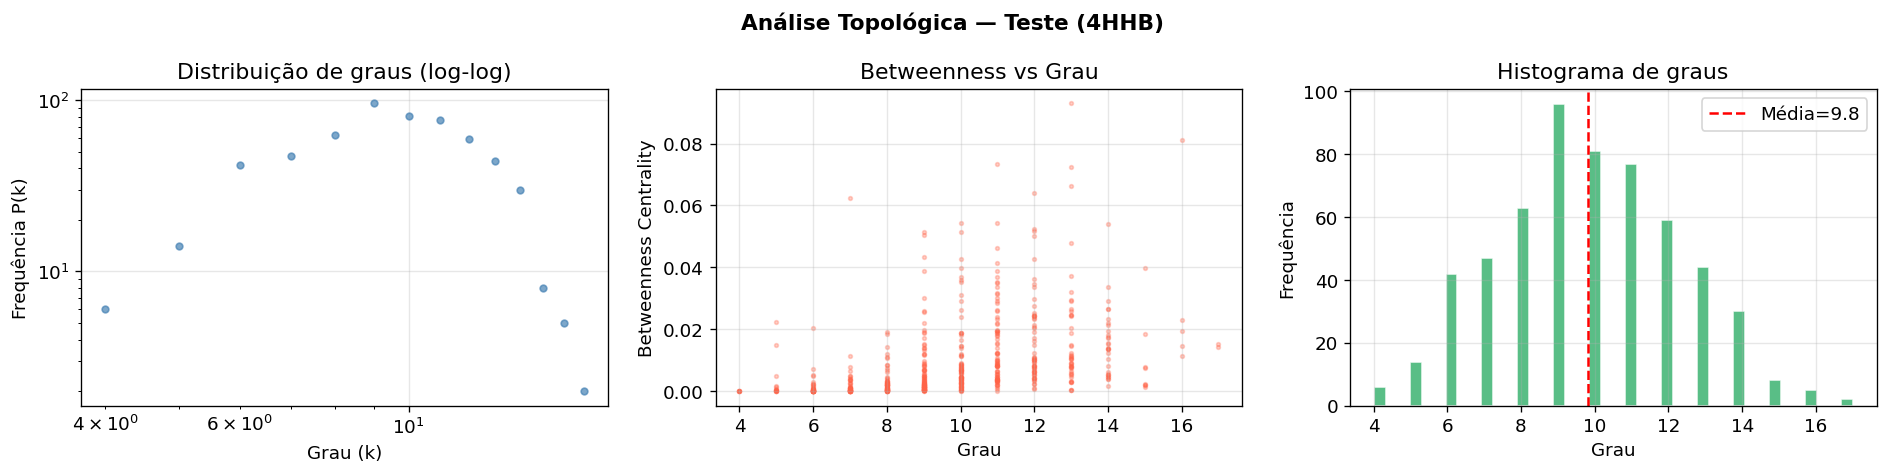

In [15]:
topo_test = topological_analysis(G_test, title=f"Teste ({TEST_ID})")

In [16]:
partition_test = detect_communities_louvain(G_test, resolution=1.0)

Executando detecção de comunidades (Louvain)...

Comunidades detectadas : 16
Modularidade           : 0.8114
Maior comunidade       : 61 nós
Menor comunidade       : 17 nós
Tamanho médio          : 35.9 ± 13.7

Distribuição de tamanhos:
  Comunidade   0:     61 nós
  Comunidade   1:     55 nós
  Comunidade   2:     52 nós
  Comunidade   3:     50 nós
  Comunidade   4:     46 nós
  Comunidade   5:     44 nós
  Comunidade   6:     37 nós
  Comunidade   7:     32 nós
  Comunidade   8:     32 nós
  Comunidade   9:     32 nós
  Comunidade  10:     32 nós
  Comunidade  11:     29 nós
  Comunidade  12:     19 nós
  Comunidade  13:     18 nós
  Comunidade  14:     18 nós
  Comunidade  15:     17 nós


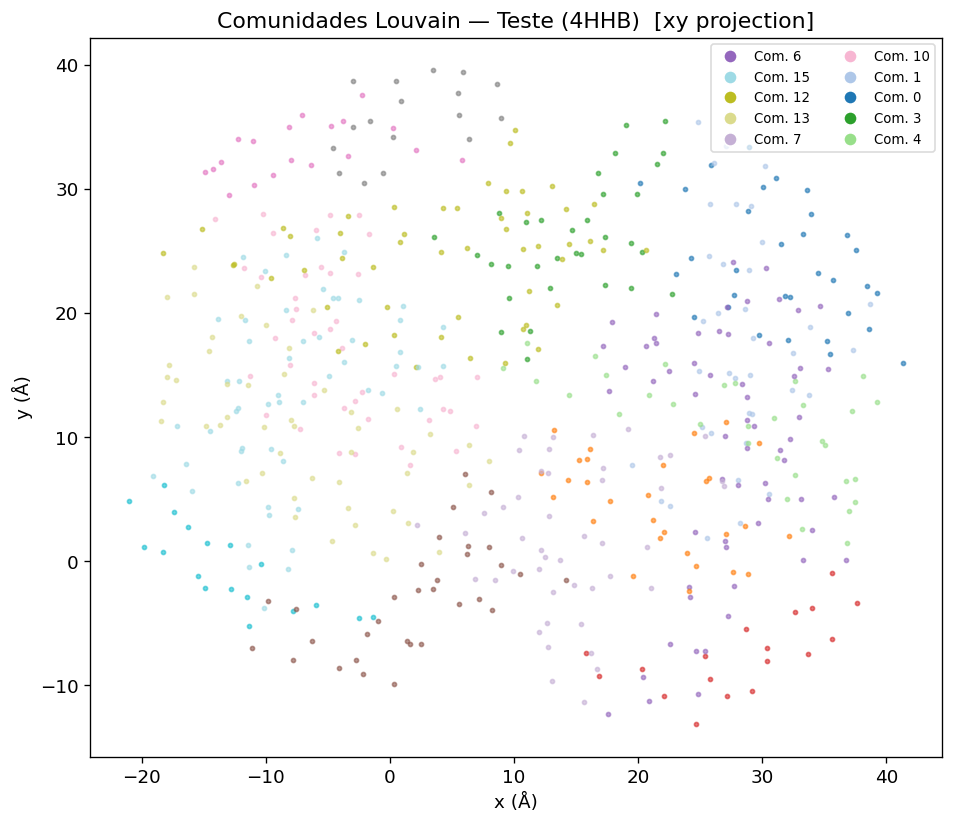

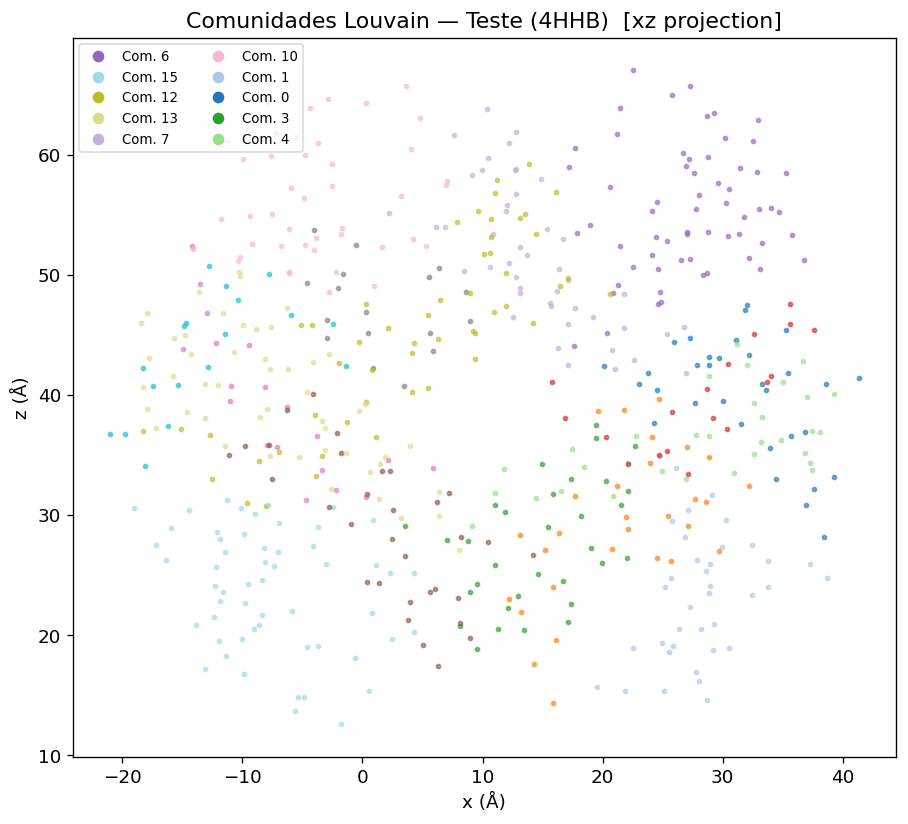

In [17]:
plot_communities_2d(G_test, partition_test, df_test, title=f"Teste ({TEST_ID})", projection="xy")
plot_communities_2d(G_test, partition_test, df_test, title=f"Teste ({TEST_ID})", projection="xz")


Pureza média das comunidades: 0.946
(1.0 = cada comunidade contém resíduos de apenas uma anotação)

Resumo por comunidade (top-30 linhas):
 community               annotation  count
         0 Hemoglobin subunit alpha     32
         1 Hemoglobin subunit alpha     37
         2 Hemoglobin subunit alpha     19
         2  Hemoglobin subunit beta     10
         3 Hemoglobin subunit alpha     32
         4 Hemoglobin subunit alpha     21
         4  Hemoglobin subunit beta     11
         5  Hemoglobin subunit beta     18
         6  Hemoglobin subunit beta     61
         7  Hemoglobin subunit beta     46
         8  Hemoglobin subunit beta     32
         9 Hemoglobin subunit alpha     19
        10 Hemoglobin subunit alpha     44
        11 Hemoglobin subunit alpha     17
        12 Hemoglobin subunit alpha     52
        13  Hemoglobin subunit beta     41
        13 Hemoglobin subunit alpha      9
        14  Hemoglobin subunit beta     18
        15  Hemoglobin subunit beta     55


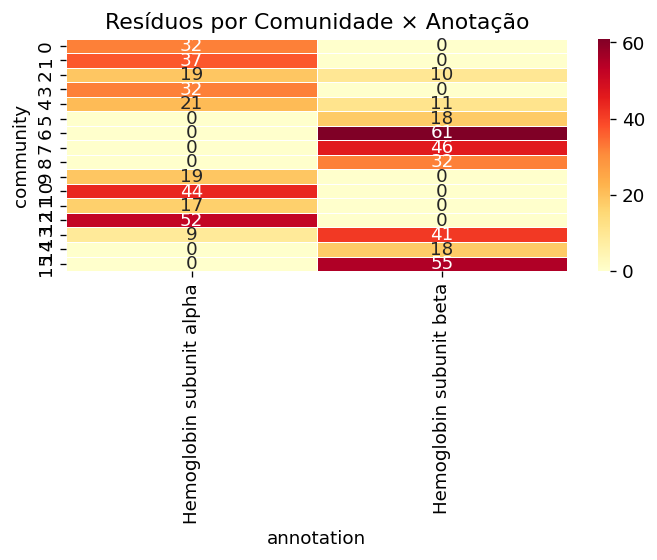


=== Teste inicial (4HHB) ===
  n_communities  : 16
  modularity     : 0.8114
  ARI            : 0.1212
  NMI            : 0.3442


In [18]:
summary_test = validate_communities(partition_test, df_test, chain_map_test)
_ = evaluate_and_print(partition_test, ground_truth_test, G_test, label=f"Teste inicial ({TEST_ID})")

---
## Calibragem de parâmetros (Grid Search)

Exploramos sistematicamente combinações de `cutoff` (densidade da rede) e
`resolution` (granularidade do Louvain), usando ARI e NMI contra o ground truth
para eleger a melhor configuração.

In [19]:
CUTOFFS     = [6.0, 7.0, 8.0, 9.0, 10.0]   # Å
RESOLUTIONS = [0.5, 1.0, 1.5, 2.0]          # Louvain resolution
N_RUNS      = 3   # média de N seeds (Louvain é estocástico)

results = []
total = len(CUTOFFS) * len(RESOLUTIONS)
print(f"Grid search: {len(CUTOFFS)} cutoffs × {len(RESOLUTIONS)} resolutions = {total} combinações")
print(f"Cada combinação roda {N_RUNS}× → {total * N_RUNS} execuções Louvain\n")

for cutoff in CUTOFFS:
    print(f"── cutoff={cutoff} Å...")
    G_tmp = build_contact_network(df_test, cutoff=cutoff)

    for resolution in RESOLUTIONS:
        aris, nmis, mods, n_comms = [], [], [], []

        for seed in range(N_RUNS):
            part = community_louvain.best_partition(
                G_tmp, weight="weight", resolution=resolution, random_state=seed
            )
            ari, nmi = compute_ari_nmi(part, ground_truth_test)
            mod = community_louvain.modularity(part, G_tmp, weight="weight")
            aris.append(ari); nmis.append(nmi)
            mods.append(mod); n_comms.append(len(set(part.values())))

        row = {
            "cutoff":        cutoff,
            "resolution":    resolution,
            "n_communities": round(np.mean(n_comms), 1),
            "modularity":    round(np.mean(mods), 4),
            "ARI":           round(np.mean(aris), 4),
            "ARI_std":       round(np.std(aris),  4),
            "NMI":           round(np.mean(nmis), 4),
            "NMI_std":       round(np.std(nmis),  4),
        }
        results.append(row)
        print(f"   res={resolution:.1f}  comms={row['n_communities']:.0f}  "
              f"ARI={row['ARI']:.3f}±{row['ARI_std']:.3f}  "
              f"NMI={row['NMI']:.3f}±{row['NMI_std']:.3f}  Q={row['modularity']:.3f}")

df_results = pd.DataFrame(results)
print("\nGrid search concluído.")
display(df_results.sort_values("ARI", ascending=False))

Grid search: 5 cutoffs × 4 resolutions = 20 combinações
Cada combinação roda 3× → 60 execuções Louvain

── cutoff=6.0 Å...


Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 249.94it/s]

Grafo construído: 574 nós, 1753 arestas.
   res=0.5  comms=24  ARI=0.082±0.002  NMI=0.336±0.010  Q=0.866


   res=1.0  comms=18  ARI=0.110±0.009  NMI=0.353±0.014  Q=0.870
   res=1.5  comms=25  ARI=0.077±0.002  NMI=0.339±0.000  Q=0.867
   res=2.0  comms=27  ARI=0.074±0.004  NMI=0.341±0.009  Q=0.864
── cutoff=7.0 Å...


Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 250.33it/s]

...

Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 200.11it/s]


Grafo construído: 574 nós, 3881 arestas.
   res=0.5  comms=14  ARI=0.113±0.012  NMI=0.306±0.028  Q=0.772
   res=1.0  comms=13  ARI=0.143±0.018  NMI=0.358±0.036  Q=0.781
   res=1.5  comms=16  ARI=0.110±0.008  NMI=0.322±0.024  Q=0.779
   res=2.0  comms=19  ARI=0.098±0.002  NMI=0.325±0.009  Q=0.771
── cutoff=10.0 Å...


Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 107.50it/s]


Grafo construído: 574 nós, 5182 arestas.
   res=0.5  comms=12  ARI=0.116±0.002  NMI=0.305±0.013  Q=0.749
   res=1.0  comms=12  ARI=0.124±0.008  NMI=0.310±0.022  Q=0.757
   res=1.5  comms=14  ARI=0.114±0.002  NMI=0.317±0.017  Q=0.757
   res=2.0  comms=17  ARI=0.104±0.003  NMI=0.314±0.018  Q=0.745

Grid search concluído.


,cutoff,resolution,n_communities,modularity,ARI,ARI_std,NMI,NMI_std
13,9.0,1.0,13.0,0.7807,0.1430,0.0181,0.3576,0.0360
5,7.0,1.0,14.3,0.8421,0.1292,0.0062,0.3536,0.0024
17,10.0,1.0,12.3,0.7574,0.1243,0.0077,0.3099,0.0220
16,10.0,0.5,12.3,0.7489,0.1164,0.0015,0.3055,0.0132
8,8.0,0.5,17.0,0.8060,0.1164,0.0113,0.3379,0.0166
18,10.0,1.5,14.3,0.7566,0.1138,0.0023,0.3171,0.0171
9,8.0,1.0,15.0,0.8132,0.1135,0.0054,0.3272,0.0099
12,9.0,0.5,13.7,0.7720,0.1134,0.0122,0.3057,0.0279
14,9.0,1.5,16.3,0.7786,0.1103,0.0080,0.3224,0.0238
1,6.0,1.0,18.3,0.8702,0.1097,0.0085,0.3528,0.0141


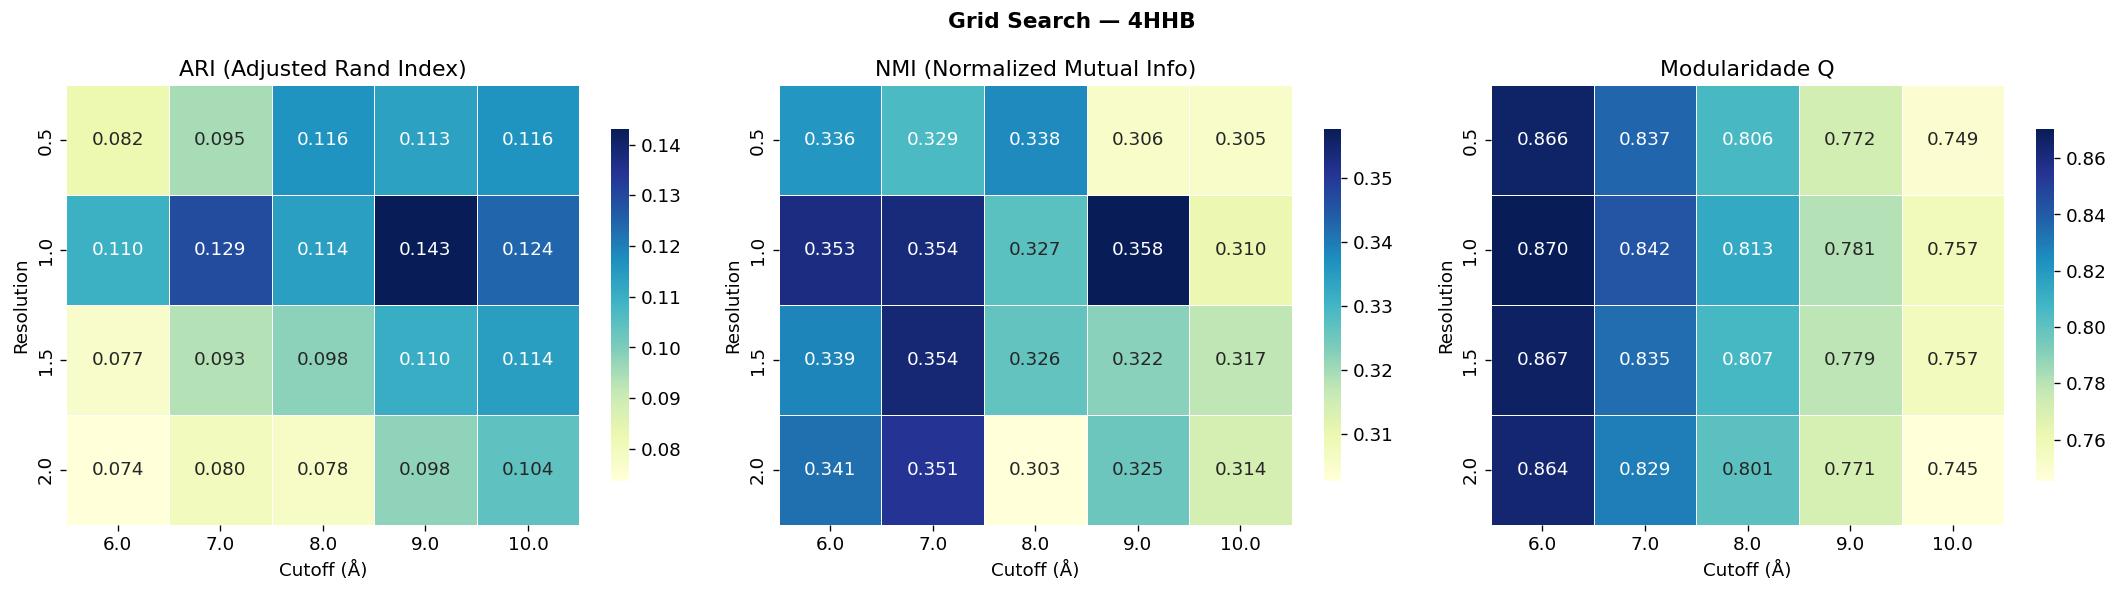

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Grid Search — {TEST_ID}", fontsize=13, fontweight="bold")

for ax, (metric, ylabel) in zip(axes, [
    ("ARI",        "ARI (Adjusted Rand Index)"),
    ("NMI",        "NMI (Normalized Mutual Info)"),
    ("modularity", "Modularidade Q"),
]):
    pivot = df_results.pivot(index="resolution", columns="cutoff", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
                vmin=pivot.values.min(), vmax=pivot.values.max())
    ax.set_title(ylabel); ax.set_xlabel("Cutoff (Å)"); ax.set_ylabel("Resolution")

plt.tight_layout()
plt.savefig(DATA_DIR / f"grid_search_{TEST_ID}.png", bbox_inches="tight", dpi=150)
plt.show()

In [21]:
# Score composto = média harmônica de ARI e NMI
df_results["score"] = (
    2 * df_results["ARI"] * df_results["NMI"]
    / (df_results["ARI"] + df_results["NMI"] + 1e-9)
)

best = df_results.loc[df_results["score"].idxmax()]

print("=" * 55)
print(" MELHOR CONFIGURAÇÃO ENCONTRADA")
print("=" * 55)
print(f"  Cutoff      : {best['cutoff']} Å")
print(f"  Resolution  : {best['resolution']}")
print(f"  Comunidades : {best['n_communities']:.0f}")
print(f"  Modularidade: {best['modularity']:.4f}")
print(f"  ARI         : {best['ARI']:.4f} ± {best['ARI_std']:.4f}")
print(f"  NMI         : {best['NMI']:.4f} ± {best['NMI_std']:.4f}")
print(f"  Score (F)   : {best['score']:.4f}")

BEST_CUTOFF     = float(best["cutoff"])
BEST_RESOLUTION = float(best["resolution"])
print(f"\n→ BEST_CUTOFF={BEST_CUTOFF}  BEST_RESOLUTION={BEST_RESOLUTION}")

 MELHOR CONFIGURAÇÃO ENCONTRADA
  Cutoff      : 9.0 Å
  Resolution  : 1.0
  Comunidades : 13
  Modularidade: 0.7807
  ARI         : 0.1430 ± 0.0181
  NMI         : 0.3576 ± 0.0360
  Score (F)   : 0.2043

→ BEST_CUTOFF=9.0  BEST_RESOLUTION=1.0


Reconstruindo rede e partição com os melhores parâmetros...


Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 124.73it/s]

Grafo construído: 574 nós, 3881 arestas.

=== Melhor config. (4HHB) ===
  n_communities  : 12
  modularity     : 0.7791
  ARI            : 0.1658
  NMI            : 0.3928


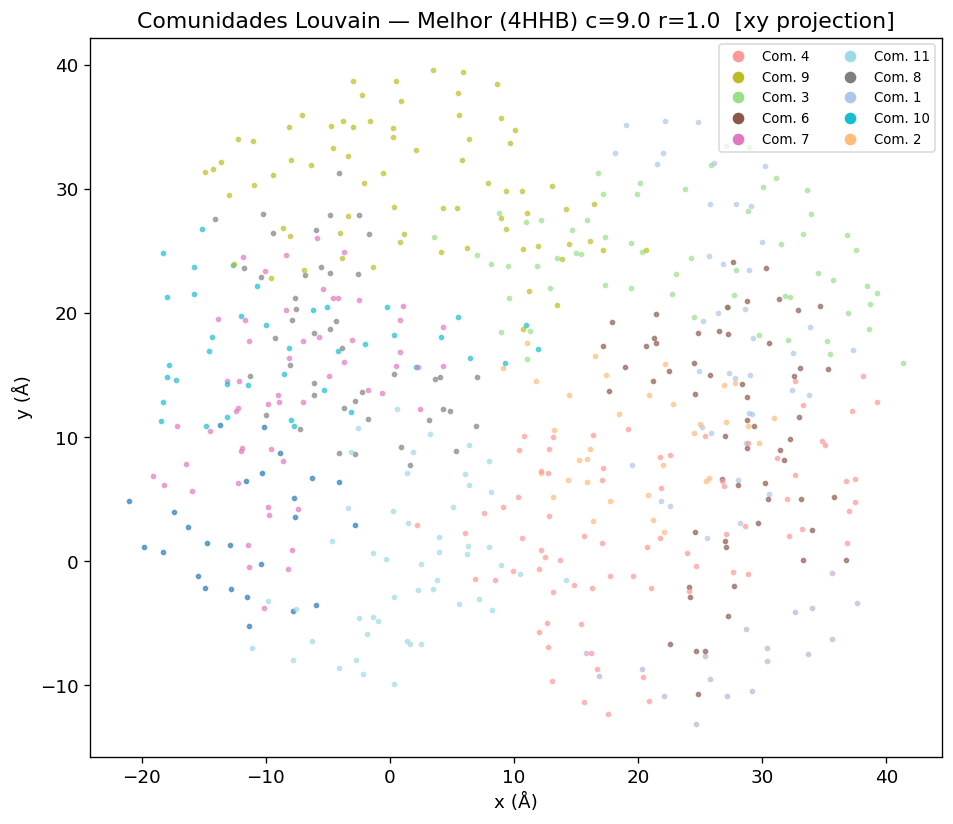


Pureza média das comunidades: 0.961
(1.0 = cada comunidade contém resíduos de apenas uma anotação)

Resumo por comunidade (top-30 linhas):
 community               annotation  count
         0  Hemoglobin subunit beta     25
         1 Hemoglobin subunit alpha     41
         2 Hemoglobin subunit alpha     34
         3 Hemoglobin subunit alpha     60
         4  Hemoglobin subunit beta     70
         4 Hemoglobin subunit alpha      6
         5  Hemoglobin subunit beta     18
         6  Hemoglobin subunit beta     58
         7  Hemoglobin subunit beta     56
         8 Hemoglobin subunit alpha     45
         9 Hemoglobin subunit alpha     72
        10 Hemoglobin subunit alpha     24
        10  Hemoglobin subunit beta     15
        11  Hemoglobin subunit beta     50


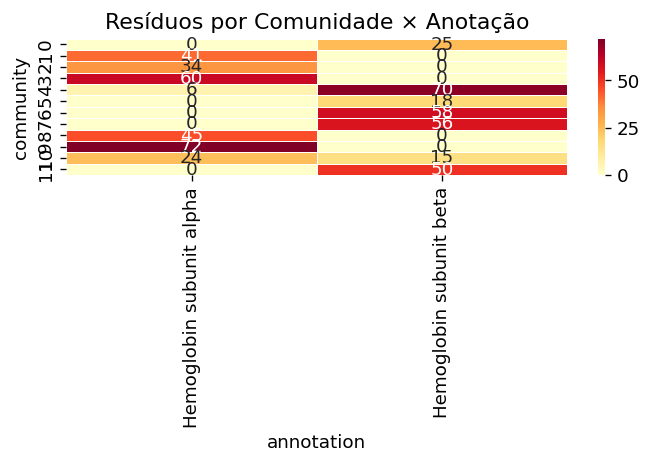

In [22]:
print("Reconstruindo rede e partição com os melhores parâmetros...")
G_best = build_contact_network(df_test, cutoff=BEST_CUTOFF)
partition_best = community_louvain.best_partition(
    G_best, weight="weight", resolution=BEST_RESOLUTION, random_state=0
)

_ = evaluate_and_print(partition_best, ground_truth_test, G_best,
                       label=f"Melhor config. ({TEST_ID})")

plot_communities_2d(G_best, partition_best, df_test,
                    title=f"Melhor ({TEST_ID}) c={BEST_CUTOFF} r={BEST_RESOLUTION}",
                    projection="xy")

summary_best = validate_communities(partition_best, df_test, chain_map_test)

---
# ETAPA B — Proteína alvo: 6B1T (Adenovírus Humano 5)

> ⚠️ **Atenção:** 6B1T é enorme (~10 GB em memória).  
> Execute somente em máquina com ≥16 GB de RAM.  
> Se necessário, substitua `TARGET_ID` por uma alternativa com ≥4 grupos funcionais:  
> - `"1AON"` — GroEL-GroES (~8500 resíduos, 21 cadeias)  
> - `"3J3Q"` — Ribossomo bacteriano completo  
> - `"5GAN"` — Vírus satélite do tabaco

In [23]:
TARGET_ID = "6B1T"   # ← troque se necessário
print(f"Alvo configurado: {TARGET_ID}")
print(f"Parâmetros herdados da Etapa A: cutoff={BEST_CUTOFF} Å | resolution={BEST_RESOLUTION}")

Alvo configurado: 6B1T
Parâmetros herdados da Etapa A: cutoff=9.0 Å | resolution=1.0


In [24]:
target_file = download_pdb(TARGET_ID)

Download concluído: datav3\6B1T.cif.gz


In [25]:
target_struct = parse_structure(target_file)

Estrutura '6B1T' carregada: 25 cadeias, 12544 resíduos.


In [26]:
df_target = get_residue_info(target_struct)
print(f"Total de resíduos no alvo: {len(df_target)}")
print(f"Cadeias presentes: {sorted(df_target['chain'].unique())}")

Resíduos padrão (aminoácidos): 12544
Total de resíduos no alvo: 12544
Cadeias presentes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [27]:
# chunk_size menor para economizar RAM em estruturas grandes
G_target = build_contact_network(df_target, cutoff=BEST_CUTOFF, chunk_size=1000)

Calculando distâncias: 100%|██████████| 13/13 [00:01<00:00, 12.05it/s]

Grafo construído: 12544 nós, 91484 arestas.



 Análise topológica: Alvo (6B1T)
Nós: 12544  |  Arestas: 91484
Grau médio: 14.59 ± 3.86
Grau máximo: 26  |  Grau mínimo: 2
Calculando centralidade de grau...
Calculando closeness centrality...
Rede grande — betweenness amostrado (k=500)...
Calculando PageRank...

Top-10 resíduos por Betweenness Centrality:
  K_97             chain=K  ALA97  BC=0.06406
  K_565            chain=K  LYS565  BC=0.06304
  K_339            chain=K  TYR339  BC=0.05917
  J_874            chain=J  PRO874  BC=0.05589
  J_778            chain=J  TYR778  BC=0.05454
  J_921            chain=J  GLU921  BC=0.05024
  E_874            chain=E  PRO874  BC=0.04994
  E_921            chain=E  GLU921  BC=0.04777
  J_771            chain=J  LEU771  BC=0.04661
  G_689            chain=G  PRO689  BC=0.04588


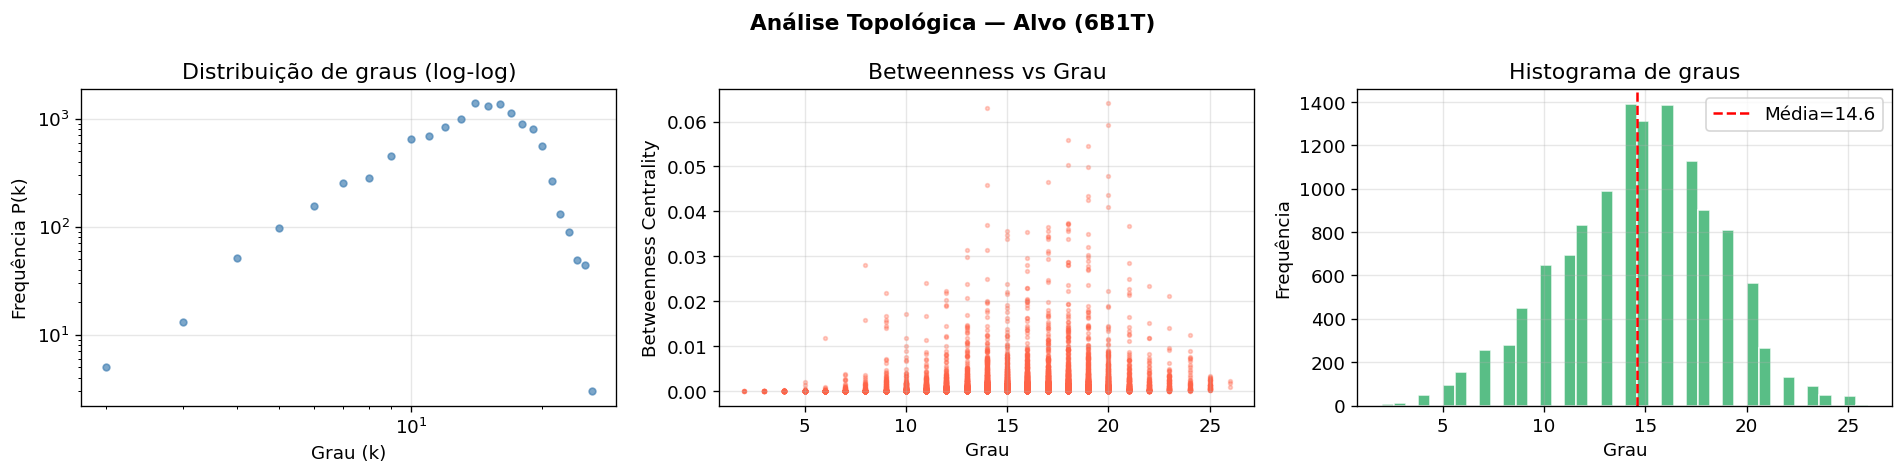

In [28]:
topo_target = topological_analysis(G_target, title=f"Alvo ({TARGET_ID})")

In [29]:
partition_target = detect_communities_louvain(G_target, resolution=BEST_RESOLUTION)

Executando detecção de comunidades (Louvain)...

Comunidades detectadas : 30
Modularidade           : 0.9008
Maior comunidade       : 727 nós
Menor comunidade       : 50 nós
Tamanho médio          : 418.1 ± 163.8

Distribuição de tamanhos:
  Comunidade   0:    727 nós
  Comunidade   1:    665 nós
  Comunidade   2:    644 nós
  Comunidade   3:    600 nós
  Comunidade   4:    594 nós
  Comunidade   5:    584 nós
  Comunidade   6:    550 nós
  Comunidade   7:    533 nós
  Comunidade   8:    527 nós
  Comunidade   9:    525 nós
  Comunidade  10:    515 nós
  Comunidade  11:    491 nós
  Comunidade  12:    468 nós
  Comunidade  13:    466 nós
  Comunidade  14:    458 nós
  Comunidade  15:    395 nós
  Comunidade  16:    394 nós
  Comunidade  17:    380 nós
  Comunidade  18:    367 nós
  Comunidade  19:    364 nós
  ... (+10 menores)


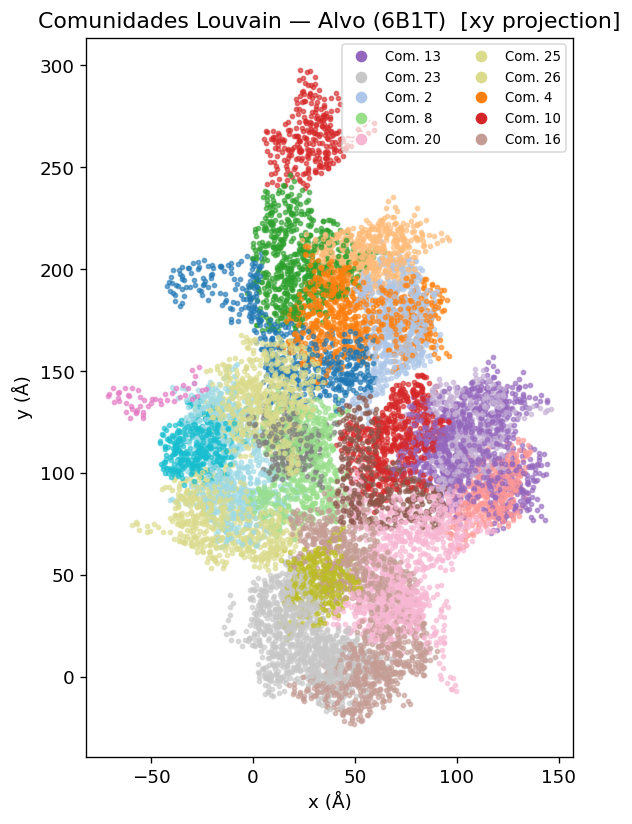

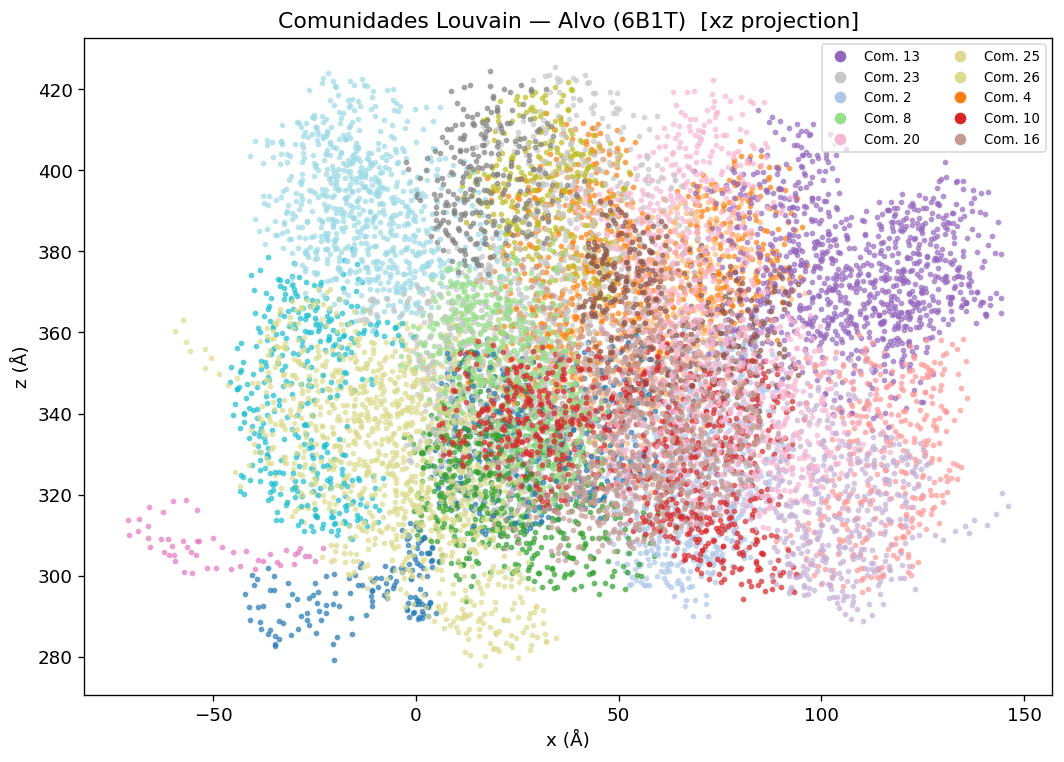

In [30]:
plot_communities_2d(G_target, partition_target, df_target,
                   title=f"Alvo ({TARGET_ID})", projection="xy")
plot_communities_2d(G_target, partition_target, df_target,
                   title=f"Alvo ({TARGET_ID})", projection="xz")

In [31]:
# Busca anotações do alvo no RCSB
chain_map_target    = fetch_chain_annotations(TARGET_ID)
ground_truth_target = build_ground_truth_from_chains(df_target, chain_map_target)

print(f"Labels únicos no alvo ({len(set(chain_map_target.values()))}):")
for label in sorted(set(chain_map_target.values())):
    print(f"  {label}")

Labels únicos no alvo (7):
  Hexon protein
  Hexon-interlacing protein
  Penton protein
  Pre-hexon-linking protein IIIa
  Pre-hexon-linking protein VIII
  Pre-histone-like nucleoprotein
  Pre-protein VI



Pureza média das comunidades: 0.931
(1.0 = cada comunidade contém resíduos de apenas uma anotação)

Resumo por comunidade (top-30 linhas):
 community                     annotation  count
         0                  Hexon protein    375
         0                 Pre-protein VI     20
         1 Pre-hexon-linking protein IIIa    130
         1                 Penton protein     15
         2                  Hexon protein    644
         3                  Hexon protein    257
         4                  Hexon protein    533
         5                  Hexon protein    491
         6                 Penton protein    160
         7                  Hexon protein    453
         7                 Pre-protein VI      8
         7                 Penton protein      5
         8                  Hexon protein    597
         8 Pre-hexon-linking protein VIII      3
         9                 Penton protein    275
        10                  Hexon protein    468
        10                 

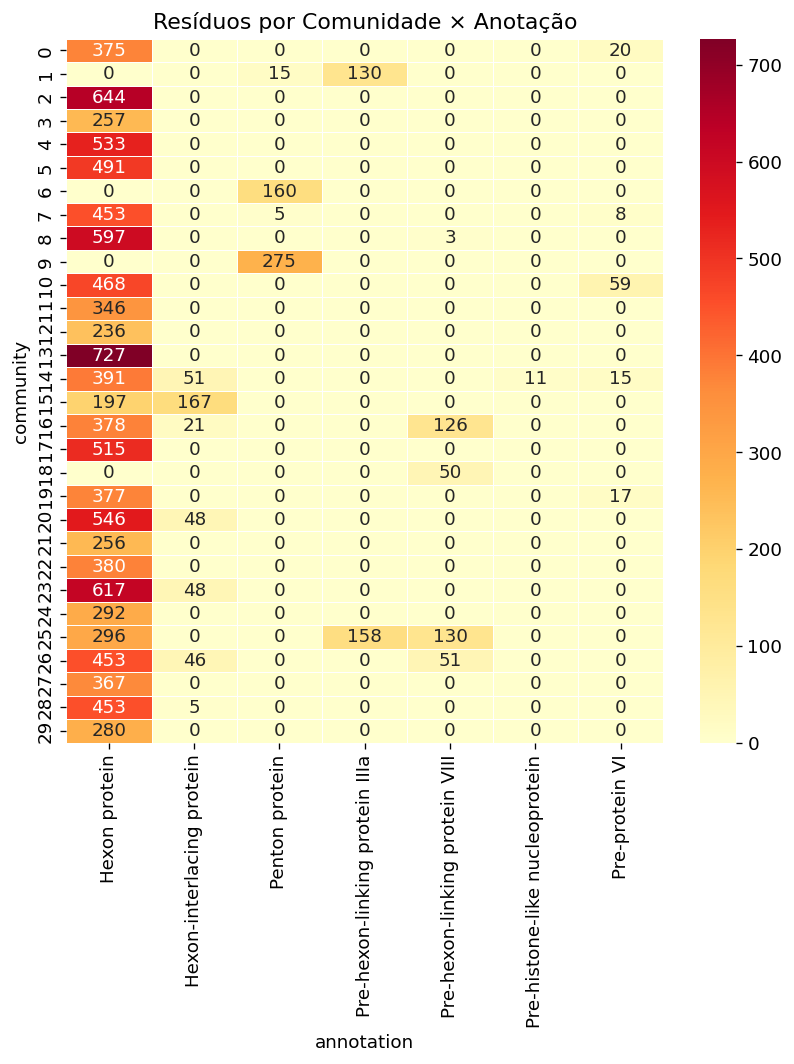


=== Alvo (6B1T) ===
  n_communities  : 30
  modularity     : 0.9008
  ARI            : 0.0114
  NMI            : 0.192


In [32]:
summary_target = validate_communities(partition_target, df_target, chain_map_target)
_ = evaluate_and_print(partition_target, ground_truth_target, G_target,
                       label=f"Alvo ({TARGET_ID})")

---
## 10. Comparação resumida: teste vs. alvo

In [33]:
def summary_table(G, partition, ground_truth, name):
    deg = np.array([d for _, d in G.degree()])
    n_comm = len(set(partition.values()))
    mod = community_louvain.modularity(partition, G, weight="weight")
    ari, nmi = compute_ari_nmi(partition, ground_truth)
    return {
        "Proteína":    name,
        "Nós":         G.number_of_nodes(),
        "Arestas":     G.number_of_edges(),
        "Grau médio":  round(deg.mean(), 2),
        "Comunidades": n_comm,
        "Modularidade":round(mod, 4),
        "ARI":         round(ari, 4),
        "NMI":         round(nmi, 4),
    }

rows = [summary_table(G_best, partition_best, ground_truth_test, f"Teste ({TEST_ID})")]

if "G_target" in dir() and "partition_target" in dir():
    rows.append(summary_table(G_target, partition_target, ground_truth_target, f"Alvo ({TARGET_ID})"))

display(pd.DataFrame(rows).set_index("Proteína"))

,Nós,Arestas,Grau médio,Comunidades,Modularidade,ARI,NMI
Proteína,,,,,,,
Teste (4HHB),574,3881,13.52,12,0.7791,0.1658,0.3928
Alvo (6B1T),12544,91484,14.59,30,0.9008,0.0114,0.1920


---
## 11. Exportar resultados

In [34]:
def save_partition(partition, df_res, filename):
    df_out = pd.DataFrame([
        {"node": n, "community": c,
         "chain":   df_res.loc[n, "chain"]   if n in df_res.index else "?",
         "resname": df_res.loc[n, "resname"] if n in df_res.index else "?",
         "resseq":  df_res.loc[n, "resseq"]  if n in df_res.index else -1}
        for n, c in partition.items()
    ])
    df_out.to_csv(filename, index=False)
    print(f"Salvo: {filename}")

save_partition(partition_best, df_test, DATA_DIR / f"partition_{TEST_ID}.csv")

if "partition_target" in dir():
    save_partition(partition_target, df_target, DATA_DIR / f"partition_{TARGET_ID}.csv")

print("\nArquivos em data/:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

Salvo: datav3\partition_4HHB.csv
Salvo: datav3\partition_6B1T.csv

Arquivos em data/:
  4HHB.cif.gz  (183 KB)
  6B1T.cif.gz  (2159 KB)
  comunidades_Alvo_(6B1T)_xy.png  (325 KB)
  comunidades_Alvo_(6B1T)_xz.png  (547 KB)
  comunidades_Melhor_(4HHB)_c=9.0_r=1.0_xy.png  (71 KB)
  comunidades_Teste_(4HHB)_xy.png  (74 KB)
  comunidades_Teste_(4HHB)_xz.png  (72 KB)
  grid_search_4HHB.png  (161 KB)
  partition_4HHB.csv  (9 KB)
  partition_6B1T.csv  (237 KB)
  topologia_Alvo_(6B1T).png  (92 KB)
  topologia_Teste_(4HHB).png  (78 KB)
  validacao_heatmap.png  (118 KB)


---
## 12. Visualização 3D inline (opcional — requer py3Dmol)

In [35]:
try:
    view_3d_communities(TEST_ID, partition_best, df_test)
except Exception as e:
    print(f"Visualização 3D indisponível: {e}")
    print("Para visualização interativa: https://www.rcsb.org/3d-view/" + TEST_ID)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.